In [13]:
# This was originally the example of obstacle avoidance from lecture.
# The repository is https://github.com/TobiaMarcucci/olrc-code/blob/main/examples/chapter4/obstacle_avoidance_dcf.ipynb
# I just made some tweaks.

import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
# Some circle obstacles each of radius 1 are created here.
radius = .1
centers = np.array([
    [.7, .3],
    [.8, .8],
    [.3, .2],
    [.3, .7],
    [.6, .6],
])

# Initial and final point.
x0 = np.array([0, 0])
xK = np.array([1, 1])
K = 20  #This is how many points are on the trajectory.

# X is 5x5 because x is 5 dim
# X(k) = [1, x1(k) x2(k) x1(k+1) x2(k+1)] * [1, x1(k) x2(k) x1(k+1) x2(k+1)]^T
X = [cp.Variable((5, 5), PSD=True) for k in range(K)]

# Objective function.
obj = 0
#     | 0   0   0   0   0 |
#     | 0   1   0  -1   0 |
# P = | 0   0   1   0  -1 |
#     | 0  -1   0   1   0 |
#     | 0   0  -1   0   1 |
P = np.zeros((5, 5))    # This is doing the QP relaxation
P[1:, 1:] = np.eye(4)
P[1:3, 3:] = - np.eye(2)
P[3:, 1:3] = - np.eye(2)
for Xk in X:
    obj += cp.trace(P @ Xk)

# Initial and final conditions.
constraints = [
    # [x1(0), x2(0)] == [0, 0]
    X[0][0, 1:3] == x0,

    # Make sure X contains x0x0^T
    X[0][1:3, 1:3] == cp.outer(x0, x0),

    # Transition Constraints to X[1]
    X[0][1:3, 3:] == cp.outer(x0, X[0][0, 3:]),

    # [x1(K), x2(K)] = [1, 1]
    X[-1][0, 3:] == xK,

    # Make sure X contains xKxK^T
    X[-1][3:, 3:] == cp.outer(xK, xK),

    # Transition Constraints from X[K-1]
    X[-1][1:3, 3:] == cp.outer(X[-1][0, 1:3], xK)]

# Coherence constraints.
for Xk in X:
    constraints.append(Xk[0, 0] == 1)
for Xk, Xkp in zip(X[:-1], X[1:]):
    constraints.append(Xk[0, 3:] == Xkp[0, 1:3])
    constraints.append(Xk[3:, 3:] == Xkp[1:3, 1:3])

# Obstacle avoidance constraints.
for Xk in X[1:]:
    for center in centers:
        P = np.zeros((5, 5))
        P[0, 0] = radius ** 2 - center.dot(center)
        P[0, 1:3] = center
        P[1:3, 0] = center
        P[1:3, 1:3] = - np.eye(2)
        constraints.append(cp.trace(P @ Xk) <= 0)

# Solve problem.
prob = cp.Problem(cp.Minimize(obj), constraints)
prob.solve(solver='MOSEK')
# Exctract optimal solution.
points = np.array([Xk[0, 1:3].value for Xk in X] + [X[-1][0, 3:].value])

# # Plot result.
# plt.figure()
# plt.axis('equal')
# for c in centers:
#     patch = Circle(c, radius, facecolor='lightcoral', edgecolor='black')
#     plt.gca().add_patch(patch)
# plt.plot(*points.T, marker='o', label=f"Relaxation value = {prob.value}")
# plt.legend()
# plt.show()

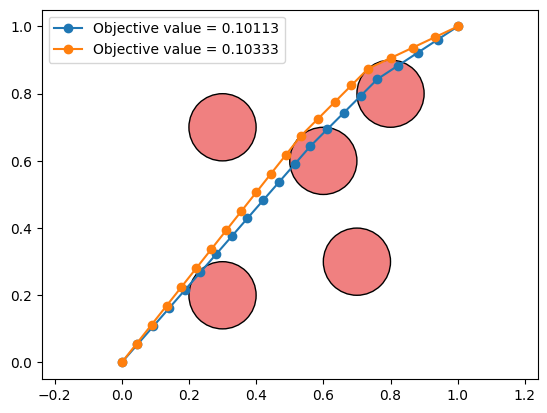

In [14]:
# Guess is now solution from relaxation
initial_points = points

def objective_function(points):
    return cp.sum_squares(points[1:] - points[:-1]) #Sum of squared distances

# Take the 2nd term in each constraint and do a 2nd order approximation of it. This is for the relaxation of nonconvex constraints
def linearized_constraint(p, p_new, c):
    diff = p - c
    dist = np.linalg.norm(diff) # In case p and c are vectors, this is the 2 norm
    offset = radius - dist
    gradient = - diff / dist
    return offset + gradient @ (p_new - p) <= 0

tol = 1e-3  # 1/1000 (for convergence)
solutions = [initial_points] # stores trajectories at all iterations for plotting
values = [objective_function(initial_points).value] # stores objective values at all iterations for showing evolution
while True:
    points = solutions[-1] # previous trajectory
    new_points = cp.Variable(points.shape)  #K different positions
    constraints = [
        new_points[0] == points[0], # initial point is fixed
        new_points[-1] == points[-1] # kth final point is fixed
        ]
    for p, p_new in zip(points, new_points):
        for c in centers:
            # linearized obstacle avoidance
            constraints.append(linearized_constraint(p, p_new, c))
    obj = objective_function(new_points)
    prob = cp.Problem(cp.Minimize(obj), constraints)
    prob.solve()

    # Convergence check.
    if (abs(values[-1] - prob.value)) / prob.value < tol:   #We now need abs since our initial guess will be better than all our next ones
        break
    solutions.append(new_points.value)
    values.append(prob.value)
# Plot result.
plt.figure()
plt.axis('equal')
for c in centers:
    patch = Circle(c, radius, facecolor='lightcoral', edgecolor='black')
    plt.gca().add_patch(patch)
for points, value in zip(solutions, values):
    rounded_value = np.round(value, 5)
    plt.plot(*points.T, marker='o', label=f"Objective value = {rounded_value}")
plt.legend()
plt.show()